In [60]:
import pandas as pd
import numpy as np

simmap_file = '../ped-sim/refined_mf.simmap'



In [61]:
%load_ext autoreload
%autoreload 2

from sex_inference_analysis import main, AnalysisParams, do_data_analysis

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
size = 30
input_file = f'../ped-sim/outputs/gp-sex/gp-sex-{size}.seg'

output_file = f'results_{size}.csv'

main(input_file=input_file, map_file=simmap_file, output_file=output_file)



male-gparent1
male-gparent2
male-gparent3
male-gparent4
male-gparent5
male-gparent6
male-gparent7
male-gparent8
male-gparent9
male-gparent10
male-gparent11
male-gparent12
male-gparent13
male-gparent14
male-gparent15
male-gparent16
male-gparent17
male-gparent18
male-gparent19
male-gparent20
male-gparent21
male-gparent22
male-gparent23
male-gparent24
male-gparent25
male-gparent26
male-gparent27
male-gparent28
male-gparent29
male-gparent30
female-gparent1
female-gparent2
female-gparent3
female-gparent4
female-gparent5
female-gparent6
female-gparent7
female-gparent8
female-gparent9
female-gparent10
female-gparent11
female-gparent12
female-gparent13
female-gparent14
female-gparent15
female-gparent16
female-gparent17
female-gparent18
female-gparent19
female-gparent20
female-gparent21
female-gparent22
female-gparent23
female-gparent24
female-gparent25
female-gparent26
female-gparent27
female-gparent28
female-gparent29
female-gparent30
writing to results_30.csv


In [67]:
final_results = f'final_results_jypter_{size}.csv'
do_data_analysis(input_file=output_file,
                 window_size=500,
                 output_file=final_results,
                 simmap=simmap_file
                 )

The start is greater than the end of the segment
The start is greater than the end of the segment


In [68]:
results_df = pd.read_csv(final_results, sep='\t')

male_results = results_df[results_df['pedigree_id'].str.contains(r'^male-')]
female_results = results_df[results_df['pedigree_id'].str.contains(r'^female-')]


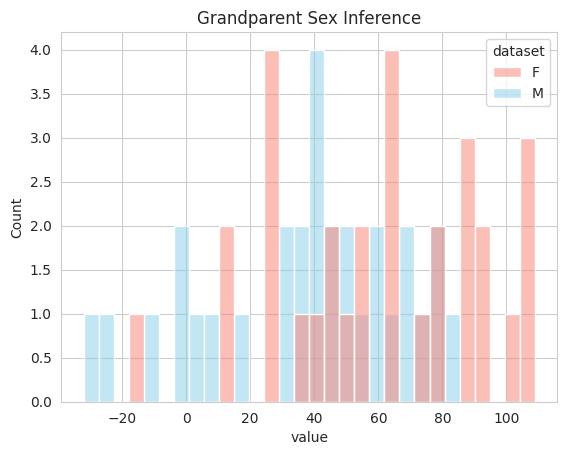

In [69]:

import seaborn as sns
import matplotlib.pyplot as plt

set1 = female_results['LOD']
set2 = male_results['LOD']


df = pd.DataFrame({
    'value': np.concatenate([set1, set2]),
    'dataset': ['F'] * len(set1) + ['M'] * len(set2)
})

# Plot
sns.histplot(
    data=df, 
    x='value', 
    hue='dataset', 
    palette={'F': 'salmon', 'M': 'skyblue'},
    alpha=0.5,
    bins=30
)

plt.title(f'Grandparent Sex Inference')

plt.show()

